<a href="https://colab.research.google.com/github/rudgich/aiml/blob/main/lab_ai_ml_5_a85205223005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [2]:
train_set = datasets.MNIST(root="data", train=True, download=True)
test_set = datasets.MNIST(root="data", train=False, download=True)

print("Training images:", train_set.data.shape)
print("Training labels:", train_set.targets.shape)
print("Test images:    ", test_set.data.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 541kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.70MB/s]

Training images: torch.Size([60000, 28, 28])
Training labels: torch.Size([60000])
Test images:     torch.Size([10000, 28, 28])


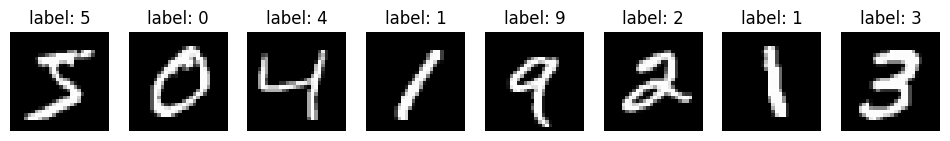

In [3]:
plt.figure(figsize=(12, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(train_set.data[i], cmap="gray")
    plt.title("label: " + str(train_set.targets[i].item()))
    plt.axis("off")
plt.show()

In [4]:
# Step 1: scale pixels from 0-255 to 0-1
X_all = train_set.data.float() / 255.0
y_all = train_set.targets

X_test = test_set.data.float() / 255.0
y_test = test_set.targets

# Step 2: first 50,000 pictures for training, last 10,000 for validation
X_train, y_train = X_all[:50000], y_all[:50000]
X_val, y_val = X_all[50000:], y_all[50000:]

print("Training set:  ", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:      ", X_test.shape)
print("Smallest pixel value:", X_train.min().item(), " Largest pixel value:", X_train.max().item())

Training set:   torch.Size([50000, 28, 28])
Validation set: torch.Size([10000, 28, 28])
Test set:       torch.Size([10000, 28, 28])
Smallest pixel value: 0.0  Largest pixel value: 1.0


In [5]:
def make_loader(X, y, shuffle):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=64, shuffle=shuffle)


train_loader = make_loader(X_train, y_train, shuffle=True)    # shuffle the training data
val_loader = make_loader(X_val, y_val, shuffle=False)         # no need to shuffle for checking
test_loader = make_loader(X_test, y_test, shuffle=False)

print("Number of training batches in one epoch:", len(train_loader))

# Look at one batch
images, labels = next(iter(train_loader))
print("One batch of images:", images.shape)
print("One batch of labels:", labels.shape)

Number of training batches in one epoch: 782
One batch of images: torch.Size([64, 28, 28])
One batch of labels: torch.Size([64])


In [6]:
def make_model(hidden=128):
    torch.manual_seed(0)    # same starting weights every time
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 10),
    )
    return model


model = make_model()
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
loss_fn = nn.CrossEntropyLoss()

In [8]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in loader:
            scores = model(images)                      # 10 scores per picture
            loss = loss_fn(scores, labels)
            predictions = scores.argmax(dim=1)          # index of the highest score

            total_loss += loss.item() * len(labels)
            total_correct += (predictions == labels).sum().item()
            total_images += len(labels)

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images
    return average_loss, accuracy

In [9]:
loss, acc = evaluate(model, val_loader)
print("Before training -> validation loss:", round(loss, 3), " validation accuracy:", round(acc, 3))

Before training -> validation loss: 2.303  validation accuracy: 0.104


In [10]:
def train_model(model, optimizer, train_loader, val_loader, epochs, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            scores = model(images)              # 1. forward pass
            loss = loss_fn(scores, labels)      # 2. compute the loss
            optimizer.zero_grad()               # 3. clear old gradients
            loss.backward()                     # 4. backward pass
            optimizer.step()                    # 5. update the weights

        # After the epoch: measure the model on both sets
        train_loss, train_acc = evaluate(model, train_loader)
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print("Epoch", epoch + 1, "of", epochs,
                  "| train loss", round(train_loss, 3), "acc", round(train_acc, 3),
                  "| val loss", round(val_loss, 3), "acc", round(val_acc, 3))

    return history

In [11]:
model_sgd = make_model()
optimizer = torch.optim.SGD(model_sgd.parameters(), lr=0.01)

history_sgd = train_model(model_sgd, optimizer, train_loader, val_loader, epochs=5)

Epoch 1 of 5 | train loss 0.691 acc 0.848 | val loss 0.649 acc 0.865
Epoch 2 of 5 | train loss 0.465 acc 0.878 | val loss 0.424 acc 0.892
Epoch 3 of 5 | train loss 0.395 acc 0.892 | val loss 0.361 acc 0.902
Epoch 4 of 5 | train loss 0.36 acc 0.899 | val loss 0.33 acc 0.908
Epoch 5 of 5 | train loss 0.338 acc 0.904 | val loss 0.311 acc 0.914


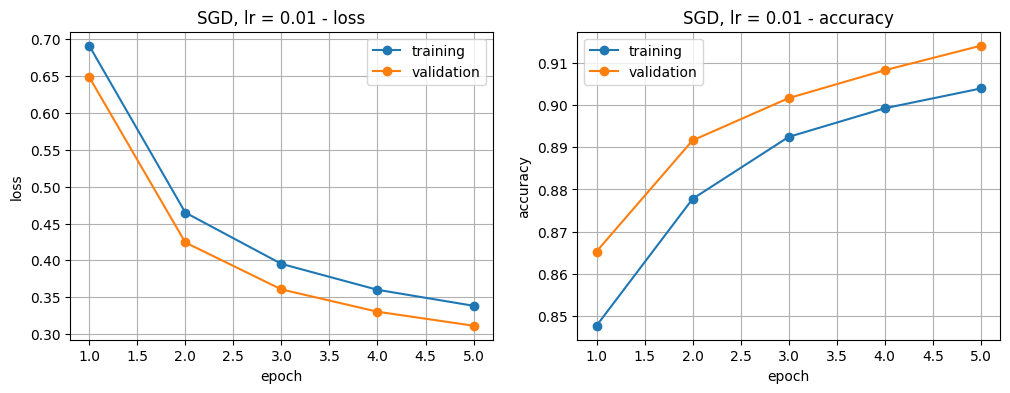

In [12]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="training")
    plt.plot(epochs, history["val_loss"], marker="o", label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " - loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="training")
    plt.plot(epochs, history["val_acc"], marker="o", label="validation")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " - accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()


plot_history(history_sgd, "SGD, lr = 0.01")

In [13]:
print("SGD with momentum")
model_momentum = make_model()
optimizer = torch.optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)
history_momentum = train_model(model_momentum, optimizer, train_loader, val_loader, epochs=5)

print()
print("Adam")
model_adam = make_model()
optimizer = torch.optim.Adam(model_adam.parameters(), lr=0.001)
history_adam = train_model(model_adam, optimizer, train_loader, val_loader, epochs=5)

SGD with momentum
Epoch 1 of 5 | train loss 0.284 acc 0.92 | val loss 0.266 acc 0.924
Epoch 2 of 5 | train loss 0.213 acc 0.938 | val loss 0.206 acc 0.941
Epoch 3 of 5 | train loss 0.167 acc 0.952 | val loss 0.167 acc 0.955
Epoch 4 of 5 | train loss 0.133 acc 0.962 | val loss 0.138 acc 0.962
Epoch 5 of 5 | train loss 0.115 acc 0.967 | val loss 0.125 acc 0.966

Adam
Epoch 1 of 5 | train loss 0.207 acc 0.941 | val loss 0.202 acc 0.944
Epoch 2 of 5 | train loss 0.139 acc 0.959 | val loss 0.146 acc 0.958
Epoch 3 of 5 | train loss 0.099 acc 0.972 | val loss 0.118 acc 0.966
Epoch 4 of 5 | train loss 0.072 acc 0.98 | val loss 0.095 acc 0.972
Epoch 5 of 5 | train loss 0.062 acc 0.982 | val loss 0.095 acc 0.972


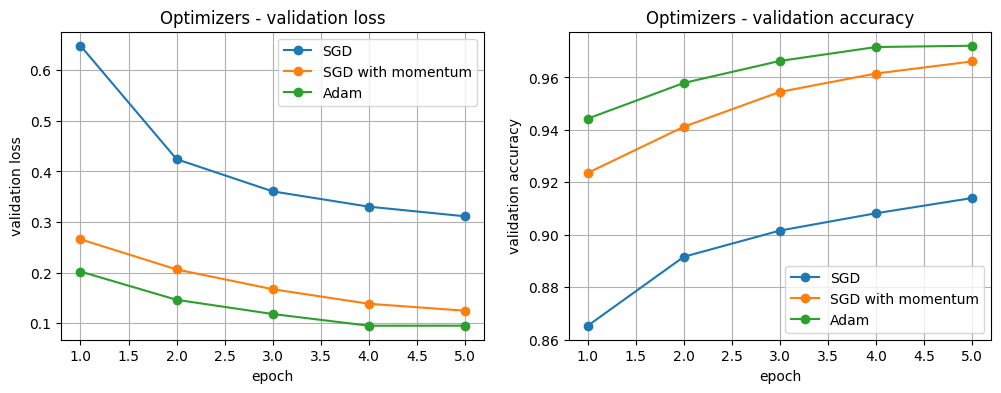

In [14]:
def plot_comparison(histories, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["val_loss"]) + 1)
        plt.plot(epochs, history["val_loss"], marker="o", label=name)
    plt.xlabel("epoch")
    plt.ylabel("validation loss")
    plt.title(title + " - validation loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], marker="o", label=name)
    plt.xlabel("epoch")
    plt.ylabel("validation accuracy")
    plt.title(title + " - validation accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()


optimizer_results = {
    "SGD": history_sgd,
    "SGD with momentum": history_momentum,
    "Adam": history_adam,
}

plot_comparison(optimizer_results, "Optimizers")

In [15]:
for name, history in optimizer_results.items():
    print(name, "-> final validation accuracy:", round(history["val_acc"][-1], 4))

SGD -> final validation accuracy: 0.914
SGD with momentum -> final validation accuracy: 0.9661
Adam -> final validation accuracy: 0.9721


In [16]:
learning_rates = [0.001, 0.01, 0.1, 3.0]
lr_results = {}

for lr in learning_rates:
    model = make_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = train_model(model, optimizer, train_loader, val_loader, epochs=5, verbose=False)

    lr_results["lr = " + str(lr)] = history
    print("lr =", lr, "-> final validation loss:", round(history["val_loss"][-1], 3),
          " final validation accuracy:", round(history["val_acc"][-1], 4))

lr = 0.001 -> final validation loss: 1.17  final validation accuracy: 0.804
lr = 0.01 -> final validation loss: 0.311  final validation accuracy: 0.914
lr = 0.1 -> final validation loss: 0.125  final validation accuracy: 0.9651
lr = 3.0 -> final validation loss: 2.102  final validation accuracy: 0.1879


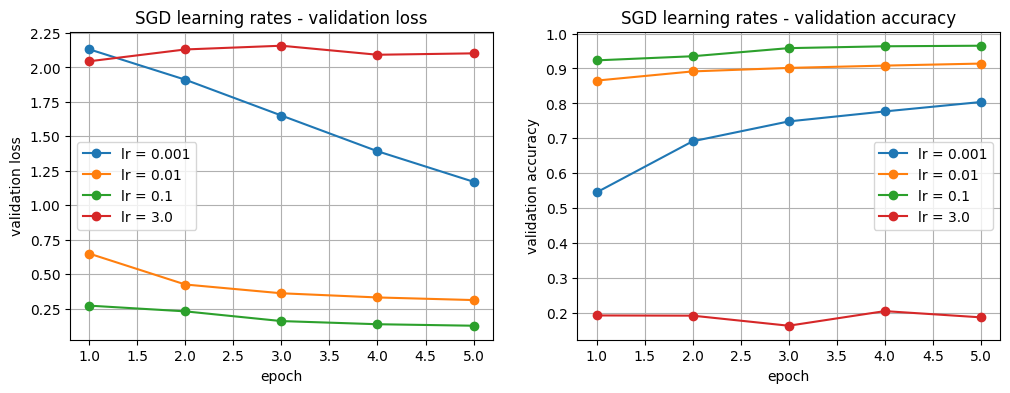

In [17]:
plot_comparison(lr_results, "SGD learning rates")

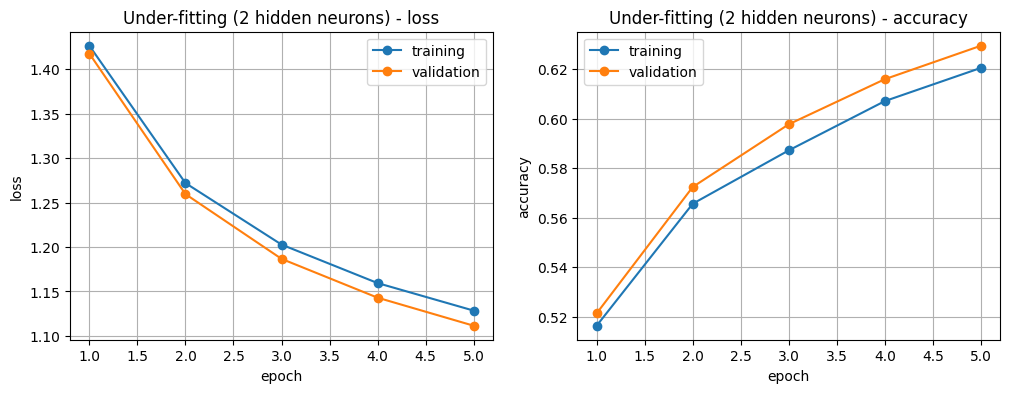

Final training accuracy:   0.62
Final validation accuracy: 0.629


In [18]:
model_small = make_model(hidden=2)
optimizer = torch.optim.Adam(model_small.parameters(), lr=0.001)
history_underfit = train_model(model_small, optimizer, train_loader, val_loader, epochs=5, verbose=False)

plot_history(history_underfit, "Under-fitting (2 hidden neurons)")
print("Final training accuracy:  ", round(history_underfit["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_underfit["val_acc"][-1], 3))

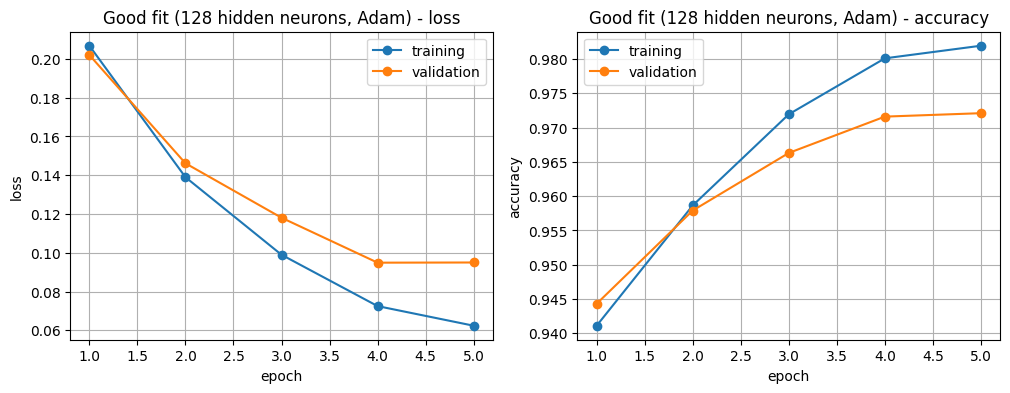

Final training accuracy:   0.982
Final validation accuracy: 0.972


In [19]:
plot_history(history_adam, "Good fit (128 hidden neurons, Adam)")
print("Final training accuracy:  ", round(history_adam["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_adam["val_acc"][-1], 3))

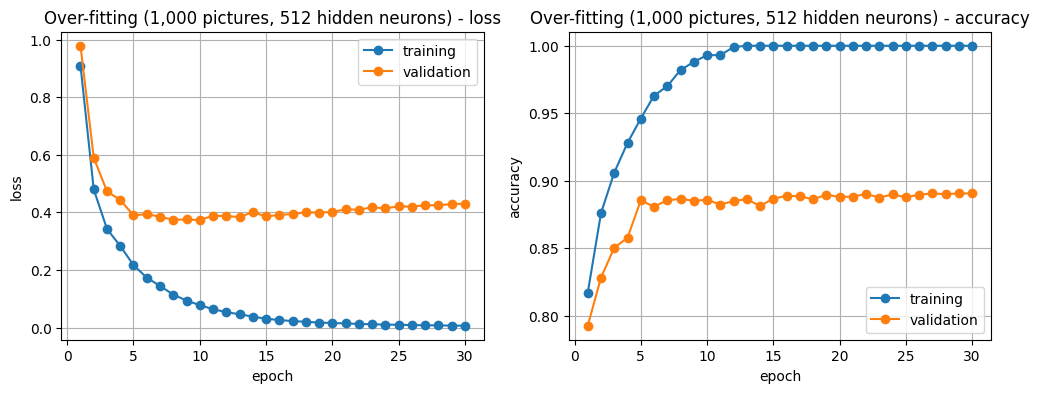

Final training accuracy:   1.0
Final validation accuracy: 0.89


In [20]:
# A small training set: only the first 1,000 pictures
small_train_loader = make_loader(X_train[:1000], y_train[:1000], shuffle=True)

model_big = make_model(hidden=512)
optimizer = torch.optim.Adam(model_big.parameters(), lr=0.001)
history_overfit = train_model(model_big, optimizer, small_train_loader, val_loader, epochs=30, verbose=False)

plot_history(history_overfit, "Over-fitting (1,000 pictures, 512 hidden neurons)")
print("Final training accuracy:  ", round(history_overfit["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_overfit["val_acc"][-1], 3))

In [23]:
val_losses = history_overfit["val_loss"]

lowest_val_loss = min(val_losses)
best_epoch = val_losses.index(lowest_val_loss) + 1     # +1 because Python counts from 0

print("Lowest validation loss:", round(lowest_val_loss, 3), "at epoch", best_epoch)
print("Validation loss at the last epoch:", round(val_losses[-1], 3))

Lowest validation loss: 0.373 at epoch 10
Validation loss at the last epoch: 0.43


In [24]:
test_loss, test_acc = evaluate(model_adam, test_loader)
print("Test loss:    ", round(test_loss, 3))
print("Test accuracy:", round(test_acc, 4))

Test loss:     0.094
Test accuracy: 0.9703


In [25]:
import tensorflow as tf

# Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Model factory: a new model with fresh weights on every call
def build_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])

# One training run with a given optimizer
def run(optimizer, epochs=5):
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        x_train, y_train,
        epochs=epochs,
        validation_data=(x_test, y_test),
        verbose=2,
    )

# Run 1: RMSprop, lr = 0.001
history_rmsprop = run(tf.keras.optimizers.RMSprop(learning_rate=0.001))

# Run 2: Adagrad, lr = 0.01
history_adagrad = run(tf.keras.optimizers.Adagrad(learning_rate=0.01))

# Run 3: SGD, lr = 0.01, momentum = 0.5
history_sgd = run(tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.5))

# Comparison of final validation accuracy
for name, h in [("RMSprop", history_rmsprop),
                ("Adagrad", history_adagrad),
                ("SGD", history_sgd)]:
    print(f"{name}: val_accuracy = {h.history['val_accuracy'][-1]:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 - 10s - 6ms/step - accuracy: 0.9261 - loss: 0.2546 - val_accuracy: 0.9523 - val_loss: 0.1621
Epoch 2/5
1875/1875 - 9s - 5ms/step - accuracy: 0.9643 - loss: 0.1202 - val_accuracy: 0.9662 - val_loss: 0.1123
Epoch 3/5
1875/1875 - 7s - 4ms/step - accuracy: 0.9747 - loss: 0.0867 - val_accuracy: 0.9747 - val_loss: 0.0909
Epoch 4/5
1875/1875 - 9s - 5ms/step - accuracy: 0.9789 - loss: 0.0693 - val_accuracy: 0.9735 - val_loss: 0.0904
Epoch 5/5
1875/1875 - 9s - 5ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9764 - val_loss: 0.0835
Epoch 1/5
1875/1875 - 10s - 6ms/step - accuracy: 0.8844 - loss: 0.4386 - val_accuracy: 0.9225 - val_loss: 0.2755
Epoch 2/5
1875/1875 - 10s - 5ms/step - accuracy: 0.9290 - loss: 0.2565 - val_accuracy: 0.9374 - val_loss: 0.2241
Epoch 3/5
1875/1875 - 9s - 5ms/step - accuracy: 0.9406 - loss: 0.2152 - val_accuracy: 0.9435 - val_loss: 0.1953
Epoch 4/5
1875/1875 - 8s - 4ms/step - accuracy: 0.

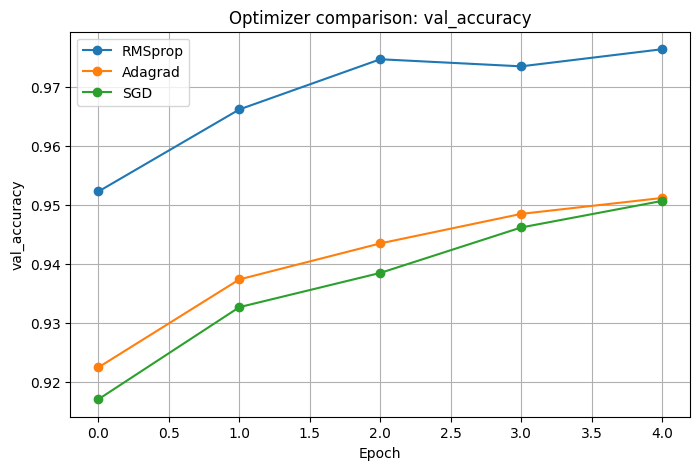

In [26]:
import matplotlib.pyplot as plt

# Exercise 1 (b)
# Keys must match the run names from the table in the task
ex1_results = {
    "RMSprop": history_rmsprop,
    "Adagrad": history_adagrad,
    "SGD": history_sgd,
}


def plot_comparison(results, metric="val_accuracy"):
    plt.figure(figsize=(8, 5))
    for name, history in results.items():
        plt.plot(history.history[metric], marker="o", label=name)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Optimizer comparison: {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_comparison(ex1_results)


In [27]:
# Exercise 1 (c)
for name, history in ex1_results.items():
    final_val_acc = history.history["val_accuracy"][-1]
    print(f"{name}: final validation accuracy = {final_val_acc:.4f}")


RMSprop: final validation accuracy = 0.9764
Adagrad: final validation accuracy = 0.9512
SGD: final validation accuracy = 0.9507


The highest final validation accuracy was obtained by Adam ([value]), and the lowest by static ([value]).

There is a mismatch. The three runs in this exercise (a)-(c) are RMSprop, Adagrad and SGD with momentum 0.5. Adam and “static” are not among them, so these names would be marked wrong if they come from Part A or from another table. The answer must name runs that appear in the output of part (c), with the values printed there.

If the table in your task uses different run names (for example “Adam” and “static” as labels), then the code in part (a) must use those optimizers and keys, and the answer is correct as written. Check this against the table.